# AAI614: Data Science & its Applications

*Notebook 4.1: Graph Analytics with cuGraph and TIGER*

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-4/Saoud-Notebook4.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




The study of network robustness is critical to the understanding of complex interconnected systems. For example, consider an example of a power grid network that is susceptible to both natural failures and targeted attacks. A natural failure occurs when a single power substation fails due to erosion of parts or natural disasters. However, when one substation fails, additional load is routed to alternative substations, potentially causing a series of cascading failures. Not all failures originate from natural causes, some come from targeted attacks, such as enemy states hacking into the grid to sabotage key equipment to maximally damage the operations of the electrical grid. A natural counterpart to network robustness is vulnerability, defined as measure of a network’s susceptibility to the dissemination of entities across the network, such as how quickly a virus spreads across a computer network.

In this lab, we show how to use [cuGraph](https://github.com/rapidsai/cugraph) and [TIGER](https://github.com/safreita1/TIGER) to conduct state-of-the-art GPU accelerated graph vulnerability and robustness analysis. Specifically, we will look at how to:

- *Quantify network vulnerability and robustness* (**Part 1**),
- *Simulate network attacks and cascading failures on networks* (**Part 2**)
- *Regulate the dissemination of computer virues on a network* (**Part 3**)

Lab Source: **NVIDIA**

## Setup
Lets begin by installing the following 2 libraries:

1.   Graph vulnerability and robustness analysis library: [TIGER](https://github.com/safreita1/TIGER)
2.   GPU acceleration library: [CuPy](https://github.com/cupy/cupy)


In [25]:
!pip install graph-tiger
!pip install stopit
!pip install fa2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 50.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fa2: filename=fa2-1.1.2-cp311-cp311-linux_x86_64.whl size=638511 sha256=8ee33a36a7d4d398c47885031223681003c3488206096d751b2a3c375839d71c
  Stored in directory: /root/.cache/pip/wheels/b0/7d/af/87e949dff5581f6a4b7ee1765dabadb2f7166afcca17947efd
Successfully built fa2


In [26]:
# This get the RAPIDS-Colab install files and test check your GPU.  Run this and the next cell only.
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible, it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.11.13 environment at: /usr
Audited 11 packages in 193ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to update your personal files.
            - If an installation failure persists when using the latest script, please make an issue on https://github.com/rapidsai-community/rapidsai-csp-utils
        ***********************************************************************
        


That's it! Now we can run a variety of GPU acclerated graph mining algorithms.



## Part 1: Quantifing network vulnerability and robustness

While CPU calculations work well for sparse graphs, GPU acceleration significantly speeds-up analysis for dense graphs. To see this, lets run the code below that measures the robustness of a Barabási Albert (BA) graph at varying levels of density (i.e., number of edges per node).

In [35]:
#import cugraph
import time
from tqdm import tqdm

from graph_tiger.measures import run_measure
from graph_tiger.graphs import graph_loader

# controls graph density by varying the number of non-zeroes per row (i.e., number of edges per node in graph)
nnz_per_row = list(range(50, 501, 50))

cpu_times = []
gpu_times = []
for nnz in tqdm(nnz_per_row):
  graph = graph_loader(graph_type='BA', n=1000, m=nnz, seed=1)

  start_cpu = time.time()
  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=int(0.05 * len(graph)))
  end_cpu = time.time()

  start_gpu = time.time()

  # ****** Replace with cuGraph version: https://docs.rapids.ai/api/cugraph/stable/api.html#module-cugraph.centrality.betweenness_centrality ******
  # 1. Compute betweenness centrality for all nodes using k random samples
  # bc_df = cugraph.betweenness_centrality(graph, k=12)
  # 2. Calculate the average score from the 'betweenness_centrality' column
  # robustness_index = bc_df["betweenness_centrality"].mean()

  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=12, use_gpu=True)
  end_gpu = time.time()


  cpu_times.append(round(end_cpu - start_cpu, 2))
  gpu_times.append(round(end_gpu - start_gpu, 2))




100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


Now lets plot the results (lower is better).

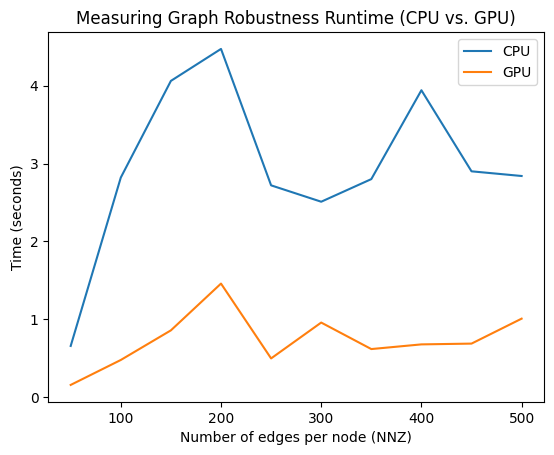

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(nnz_per_row, cpu_times, label='CPU')
plt.plot(nnz_per_row, gpu_times, label='GPU')
plt.xlabel('Number of edges per node (NNZ)')
plt.ylabel('Time (seconds)')
plt.title('Measuring Graph Robustness Runtime (CPU vs. GPU)')
plt.legend()
plt.show()

## Part 2. Simulating Cascading Failures in U.S. Electrical Grid
Cascading failures often arise as a result of natural failures or targeted attacks in a network. There are 3 main processes governing the network simulation:

- the **capacity** of each node (<img src="https://render.githubusercontent.com/render/math?math=c_v">) in the network, e.g., power substation capacity.

- the **load** of each node (<img src="https://render.githubusercontent.com/render/math?math=l_v">) in the network, e.g., power substation load level

- network **redundancy** (*r*) representing the amount of reserve capacity present in the network i.e., auxiliary support systems.

When a node is attacked it becomes "overloaded", causing it to fail and requiring the load be distributed to its neighbors. When defending a node, we increase it’s capacity to protect against attacks. With just these 3 parameters, we can setup a cascading failure simulation. Below, we show how to load a graph representing the U.S. electrical grid and setup the simulation parameters.

In [38]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('electrical')

params = {
   'runs': 10,  # number of times to run the simulation
   'steps': 100,  # number of time steps to run each simulation
   'seed': 1,  # for repoducibility

   'l': 0.8,  # network load [0, 1]
   'r': 0.2,  # network redundancey [0, 1]
   'c': int(0.1 * len(graph)),  # load capacity approximation

   'robust_measure': 'largest_connected_component',  # measure of network health
}

### Setting up a Targeted Attack
To run the attack we just have to modify a few simulation parameters. We set the attack to remove 30 nodes in the graph (e.g., power grid substations) with highest degree centrality "id_node". As you can imagine, there are many different strategies that can be used to attack the grid, however, by selecting degree centrality we can find "central" nodes in the network with many power lines (edges) connected to the substations (nodes).

In [39]:
params.update({
   'k_a': 30,  # number of nodes to attack
   'attack': 'id_node',  # attack strategy
})

Now lets run the simulation and plot the results!

In [40]:
import networkx as nx

# Swizzle to map the to_scipy_sparse_matrix function to the to_scipy_sparse_array function
if not hasattr(nx, 'to_scipy_sparse_matrix'):
    nx.to_scipy_sparse_matrix = nx.to_scipy_sparse_array

from graph_tiger.cascading import Cascading

cascading = Cascading(graph, **params)
results = cascading.run_simulation()

cascading.plot_results(results)

Running simulation 10 times


<Figure size 640x480 with 0 Axes>

### 1. Collapsing a network

Now try modifying the code to find the minimal attack necessary to collapse the electrical grid. To do this, plot the "health" of the network as measured by the robustness measure (i.e., "largest_connected_component") at the end of each simulation, against the attack strength ("k_a").

**Hint:** electrical networks are fragile to targeted attacks, try removing just a few nodes.

  0%|          | 0/6 [00:00<?, ?it/s]

Running simulation 10 times


 17%|█▋        | 1/6 [00:44<03:40, 44.12s/it]

Running simulation 10 times


 33%|███▎      | 2/6 [01:29<02:59, 44.87s/it]

...

Running simulation 10 times


 83%|████████▎ | 5/6 [03:53<00:47, 47.20s/it]

Running simulation 10 times


100%|██████████| 6/6 [04:41<00:00, 46.85s/it]


Text(0.5, 1.0, 'Effect of Attack Strength in Cascading Failures')

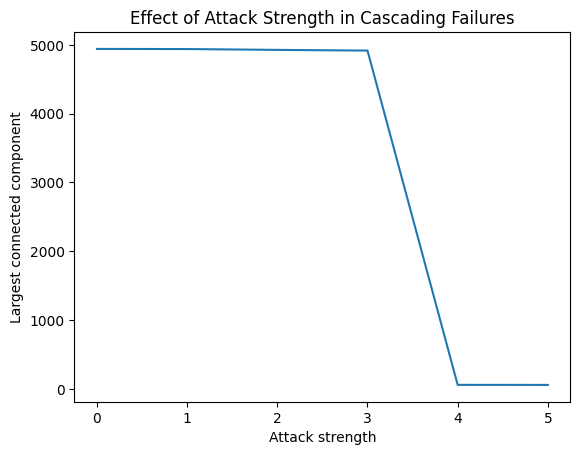

In [41]:
sim_results =[]

params['attack'] = 'id_node'
attack_strengths = list(range(0, 6, 1))

for k_a in tqdm(attack_strengths):
  params['k_a'] = k_a

  cascading = Cascading(graph, **params)
  results = cascading.run_simulation()

  lcc_at_end = results[-1]
  sim_results.append(lcc_at_end)

%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(attack_strengths, sim_results)
plt.xlabel('Attack strength')
plt.ylabel('Largest connected component')
plt.title('Effect of Attack Strength in Cascading Failures')

# Part 3. Simulating Computer Virus Spread Across Router Network

The flu-like susceptible-infected-susceptible (SIS) is a popular model that allows us to simulate the spread of viruses across networks (graphs). Each node in the SIS model can be in one of two states, infected *I* or susceptible *S*, and at each time step *t*, an infected node has a probability *β* of infecting each of it's uninfected neighbors. After this, each infected node has a probability *δ* of healing and becoming susceptible again.

It’s been shown there's a direct correlation between the graph's topology as measured through the spectral radius (largest eigenvalue) of the graph, and the virus remaining endemic. The exact relationship between a virus's strength (*s*), birth rate (*β*), death rate (*δ*) and spectral radius (*λ1*) is s=λ1⋅b/d, where a larger *s* means a stronger virus. With just these 3 parameters, we can setup a computer virus simulation.

Below, we (1) load the Autonomous systems AS-733 network, which is a graph of routers comprising the internet; and (2) setup the simulation parameters.  

In [88]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('as_733')

sis_params = {
   'runs': 10,  # number of simulations to run
   'steps': 5000,  # number of time steps to run simulation

   'model': 'SIS',
   'b': 0.00208,  # virus birth rate
   'd': 0.01,  # virus death rate
   'c': 0.3,  # fraction of the network that starts infected
}

In [89]:
import graph_tiger.utils
# Patch gpu_available to prevent ImportError due to deprecated pip._internal.utils.misc.get_installed_distributions
graph_tiger.utils.gpu_available = lambda: False

Now lets run the simulation and plot the results! In the figure below, we see that without intervention the virus remains endemic on the router network.

Running simulation 10 times


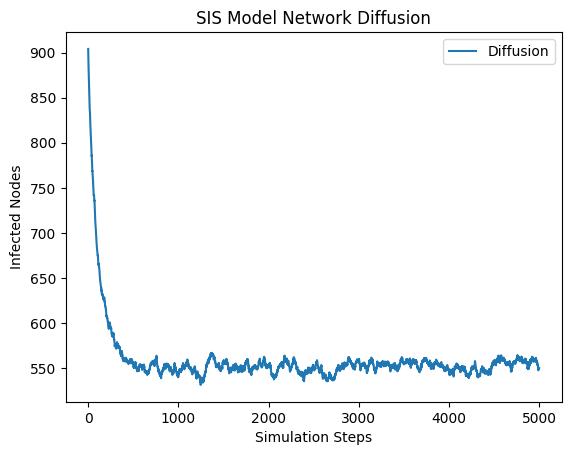

In [92]:
import matplotlib.pyplot as plt
from graph_tiger.diffusion import Diffusion

# 1. Initialize and run the simulation
diffusion = Diffusion(graph, **sis_params)
results = diffusion.run_simulation()

# 2. FIX: Bypass TIGER's buggy saver and plot the raw results array directly
plt.figure(figsize=(6.4, 4.8))
plt.plot(results, label=sis_params.get('method', 'Diffusion'))

# 3. Add necessary canvas labels
plt.title("SIS Model Network Diffusion")
plt.xlabel("Simulation Steps")
plt.ylabel("Infected Nodes")
plt.legend()
plt.show()


While we do not have control over the virus strength (*s*), we can maniuplate the underlying toplogy of the router network to make it harder for the virus to spread. The question is, how do we optimally modify the network to reduce the spread of the virus? While a naive solution may be to disconnect the whole network, this isn't very practical since everyone would loose internet access! Instead, we need a strategy that carefully vaccinates a few nodes (routers) against the virus.

### 2. Optimally Vaccinating a Network

Now lets compare the efficacy of 4 vaccination strategies when vaccinating only 3 nodes in the network:

1. [netshield](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ns) ('ns_node')
2. [id_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_id) ('id_node')
2. [rd_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_rd) ('rd_node')
3. [ib_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ib) ('ib_node')

To implement a defense strategy you just have to modify a few simulation parameters.

In [93]:
sis_params.update({
    'diffusion': 'min',  # we want to minimize the ability of the virus to propagate,
    'method': 'ns_node',  # use the Netshield technique
    'k': 5  # vaccinate 5 nodes according the selected strategy
})

Does each strategy manage to contain the virus (i.e., less than 1\% infected population)? Which strategy has the lowest infected population at the end of the simulation? Setup and run each simulation and compare the results to the unvaccinated network.

Running simulation 10 times
Percent of network that remains infected at end of simulation using id_node vaccination technique is 8.31%
Running simulation 10 times
Percent of network that remains infected at end of simulation using rd_node vaccination technique is 8.31%
Running simulation 10 times
Percent of network that remains infected at end of simulation using pr_node vaccination technique is 8.76%


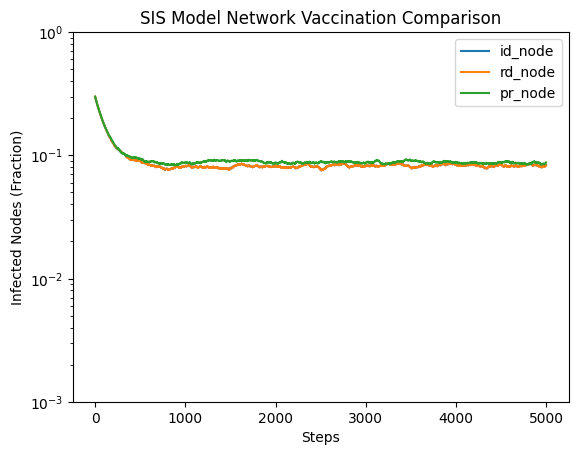

In [94]:
import matplotlib.pyplot as plt

methods = ['id_node', 'rd_node', 'pr_node']

# 1. Create a dictionary to hold the results of all techniques
all_results = {}

for method in methods:
    sis_params['method'] = method

    diffusion = Diffusion(graph, **sis_params)
    results = diffusion.run_simulation()

    # Store the results to plot them together
    all_results[method] = results

    print('Percent of network that remains infected at end of simulation using {} vaccination technique is {}%'.format(
        method, round((results[-1] / len(graph)) * 100, 2))
    )

# 2. Plot all techniques on the same graph symmetrically
plt.figure(figsize=(6.4, 4.8))

for method, res in all_results.items():
    # Normalize by graph length to show fraction of infected nodes
    normalized_res = [r / len(graph) for r in res]
    plt.plot(normalized_res, label=method)

plt.xlabel('Steps')
plt.ylabel('Infected Nodes (Fraction)')
plt.title('SIS Model Network Vaccination Comparison')
plt.legend()
plt.yscale('log') # TIGER diffusion examples traditionally use log scale
plt.ylim(0.001, 1)
plt.show()
